In [ ]:
# ShreeRama Jayanth
# 801239262
# Homework 1

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
file_path = '/content/drive/My Drive/IntroToML/D3.csv'
df = pd.read_csv(file_path)

In [ ]:
X1 = df.values[:,0]
X2 = df.values[:,1]
X3 = df.values[:,2]
y = df.values[:,3]
m = len(y)
print(m)

100


In [ ]:
def compute_cost(X, y, theta):
  predictions = X.dot(theta)
  errors = np.subtract(predictions, y)
  sqrErrors = np.square(errors)
  J = 1 / (2 * m) * np.sum(sqrErrors)
  return J

In [ ]:
def gradient_descent(X, y, theta, alpha, iterations):
  m = len(y)
  theta = theta.copy()
  cost_history = np.zeros(iterations)

  for i in range(iterations):
    predictions = X.dot(theta)
    errors = np.subtract(predictions, y)
    sum_delta = (alpha / m) * X.transpose().dot(errors)
    theta = theta - sum_delta
    cost_history[i] = compute_cost(X, y, theta)
  return theta, cost_history

In [ ]:
iterations = 1500
learning_rates = [0.1, 0.05, 0.01]

variables_p1 = {'X1': X1, 'X2': X2, 'X3': X3}
results_p1 = {}  # results_p1[name][alpha] = (theta, cost_history)

for name, Xi in variables_p1.items():
    X_0 = np.ones((m, 1))
    X_1 = Xi.reshape(m, 1)
    X_mat = np.hstack((X_0, X_1))

    results_p1[name] = {}
    for alpha in learning_rates:
        theta = np.zeros(2)
        theta, cost_history = gradient_descent(X_mat, y, theta, alpha, iterations)
        results_p1[name][alpha] = (theta, cost_history)
        print(f'{name}: alpha={alpha:<5} theta={theta}  final cost={cost_history[-1]:.6f}')

X1: alpha=0.1   theta=[ 5.92794892 -2.03833663]  final cost=0.984993
X1: alpha=0.05  theta=[ 5.9279486  -2.03833651]  final cost=0.984993
X1: alpha=0.01  theta=[ 5.71850653 -1.9568206 ]  final cost=0.990589
X2: alpha=0.1   theta=[0.73606043 0.55760761]  final cost=3.599366
X2: alpha=0.05  theta=[0.73606041 0.55760762]  final cost=3.599366
X2: alpha=0.01  theta=[0.71988473 0.56390334]  final cost=3.599399
X3: alpha=0.1   theta=[ 2.8714221  -0.52048288]  final cost=3.629451
X3: alpha=0.05  theta=[ 2.87142199 -0.52048284]  final cost=3.629451
X3: alpha=0.01  theta=[ 2.78048129 -0.48451631]  final cost=3.630526


In [ ]:
best_alpha_p1 = {}
for name in variables_p1:
    best_alpha = min(results_p1[name], key=lambda a: results_p1[name][a][1][-1])
    best_alpha_p1[name] = best_alpha
    theta, cost_history = results_p1[name][best_alpha]
    print(f'{name}: Y = {theta[0]:.4f} + {theta[1]:.4f} * {name}   '
          f'(alpha={best_alpha}, final cost={cost_history[-1]:.6f})')

X1: Y = 5.9279 + -2.0383 * X1   (alpha=0.1, final cost=0.984993)
X2: Y = 0.7361 + 0.5576 * X2   (alpha=0.1, final cost=3.599366)
X3: Y = 2.8714 + -0.5205 * X3   (alpha=0.1, final cost=3.629451)


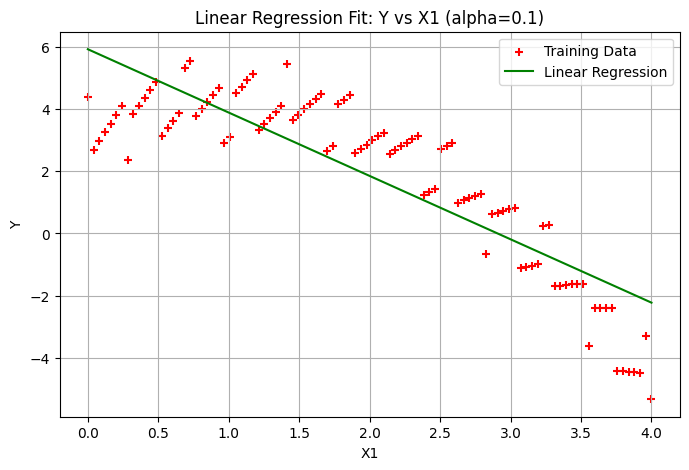

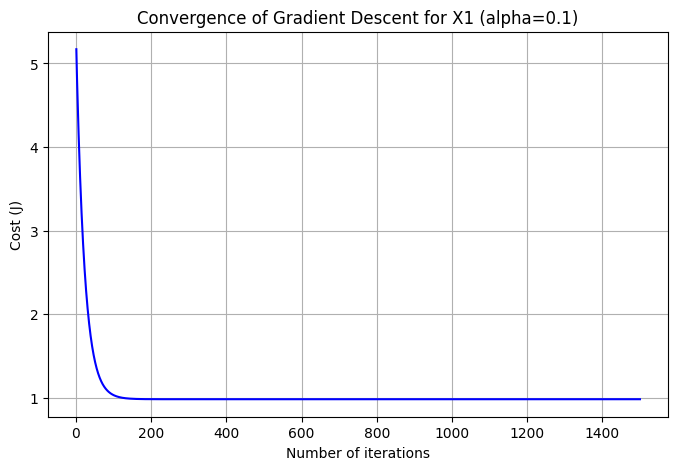

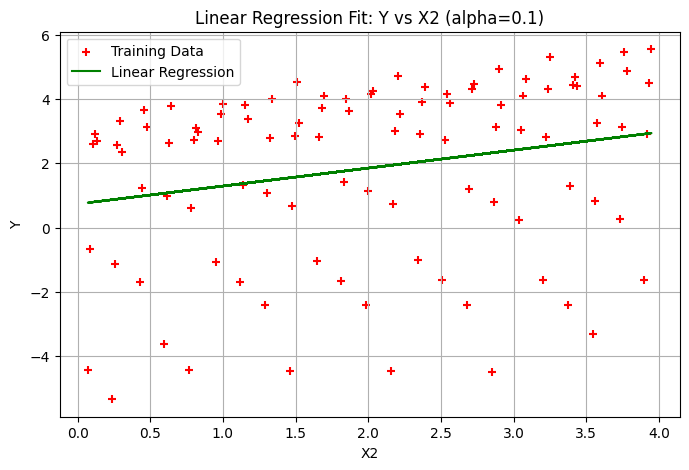

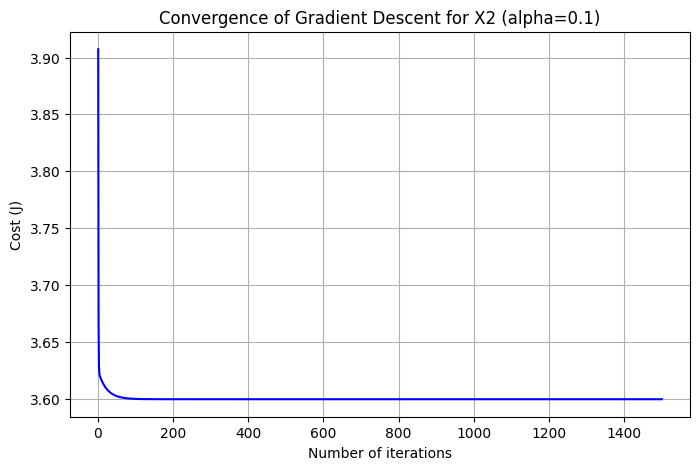

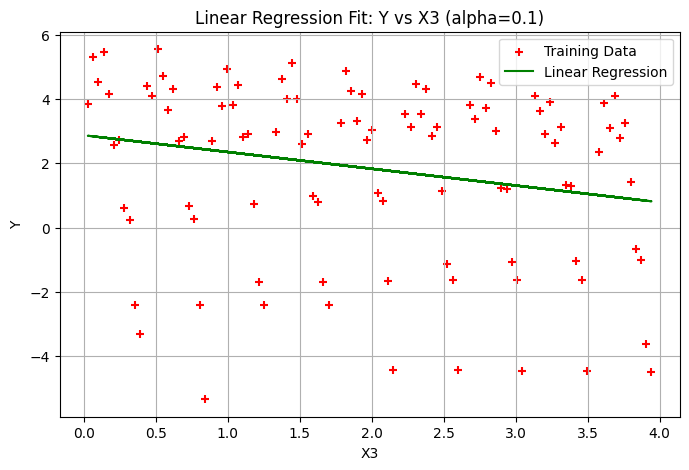

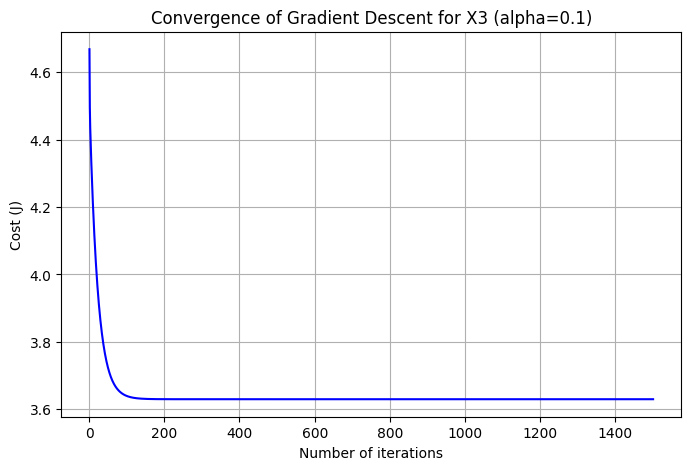

In [ ]:
for name, Xi in variables_p1.items():
    alpha = best_alpha_p1[name]
    theta, cost_history = results_p1[name][alpha]
    X_mat = np.hstack((np.ones((m, 1)), Xi.reshape(m, 1)))

    # Regression fit plot
    plt.figure(figsize=(8, 5))
    plt.scatter(Xi, y, color='red', marker='+', label='Training Data')
    plt.plot(Xi, X_mat.dot(theta), color='green', label='Linear Regression')
    plt.grid(True)
    plt.xlabel(name)
    plt.ylabel('Y')
    plt.title(f'Linear Regression Fit: Y vs {name} (alpha={alpha})')
    plt.legend()
    plt.show()

    # Cost history plot
    plt.figure(figsize=(8, 5))
    plt.plot(range(1, iterations + 1), cost_history, color='blue')
    plt.grid(True)
    plt.xlabel('Number of iterations')
    plt.ylabel('Cost (J)')
    plt.title(f'Convergence of Gradient Descent for {name} (alpha={alpha})')
    plt.show()

In [ ]:
for name in variables_p1:
    alpha = best_alpha_p1[name]
    final_cost = results_p1[name][alpha][1][-1]
    print(f'{name}: final cost = {final_cost:.6f}')

best_variable = min(best_alpha_p1, key=lambda n: results_p1[n][best_alpha_p1[n]][1][-1])
print(f'\nLowest cost achieved by: {best_variable}')

X1: final cost = 0.984993
X2: final cost = 3.599366
X3: final cost = 3.629451

Lowest cost achieved by: X1


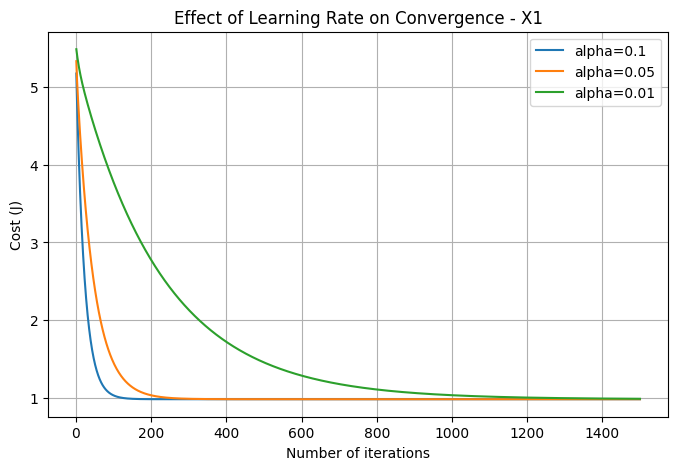

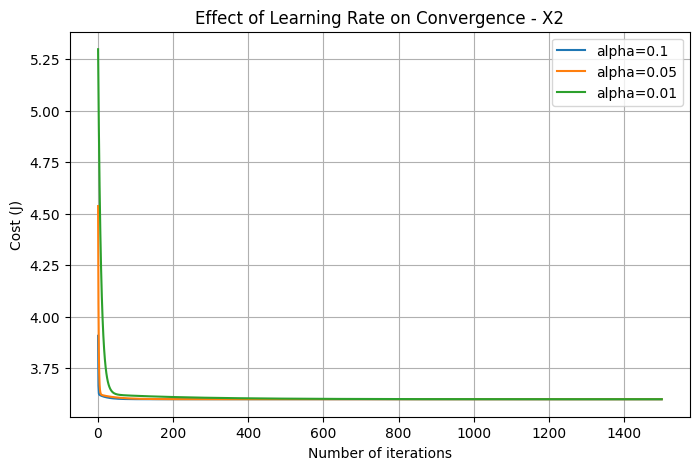

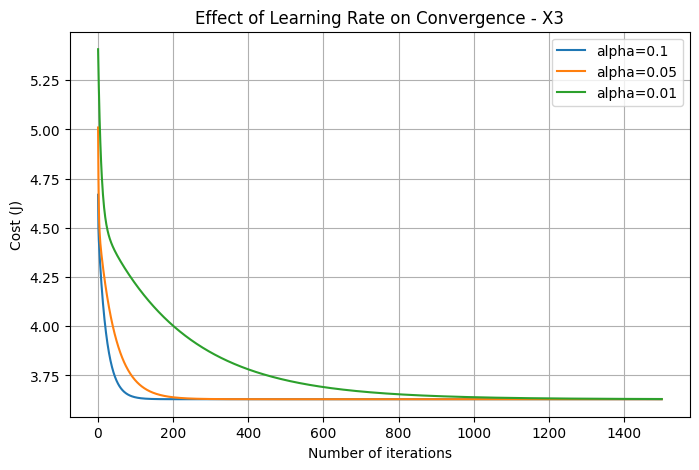

In [ ]:
for name in variables_p1:
    plt.figure(figsize=(8, 5))
    for alpha in learning_rates:
        cost_history = results_p1[name][alpha][1]
        plt.plot(range(1, iterations + 1), cost_history, label=f'alpha={alpha}')
    plt.grid(True)
    plt.xlabel('Number of iterations')
    plt.ylabel('Cost (J)')
    plt.title(f'Effect of Learning Rate on Convergence - {name}')
    plt.legend()
    plt.show()

In [ ]:
X_0 = np.ones((m, 1))
X_all = np.hstack((X_0, X1.reshape(m, 1), X2.reshape(m, 1), X3.reshape(m, 1)))

results_p2 = {}  # results_p2[alpha] = (theta, cost_history)
for alpha in learning_rates:
    theta = np.zeros(4)
    theta, cost_history = gradient_descent(X_all, y, theta, alpha, iterations)
    results_p2[alpha] = (theta, cost_history)
    print(f'alpha={alpha:<5} theta={theta}  final cost={cost_history[-1]:.6f}')

alpha=0.1   theta=[ 5.31416563 -2.00371905  0.53256359 -0.26560164]  final cost=0.738464
alpha=0.05  theta=[ 5.31128136 -2.0033116   0.5330402  -0.26517886]  final cost=0.738465
alpha=0.01  theta=[ 4.15118728 -1.8394291   0.72473856 -0.09513266]  final cost=0.810510


In [ ]:
best_alpha_p2 = min(results_p2, key=lambda a: results_p2[a][1][-1])
theta_best, cost_history_best = results_p2[best_alpha_p2]

print(f'Best learning rate: alpha = {best_alpha_p2}')
print(f'Final cost: {cost_history_best[-1]:.6f}')
print(f'Y = {theta_best[0]:.4f} + {theta_best[1]:.4f}*X1 + '
      f'{theta_best[2]:.4f}*X2 + {theta_best[3]:.4f}*X3')

Best learning rate: alpha = 0.1
Final cost: 0.738464
Y = 5.3142 + -2.0037*X1 + 0.5326*X2 + -0.2656*X3


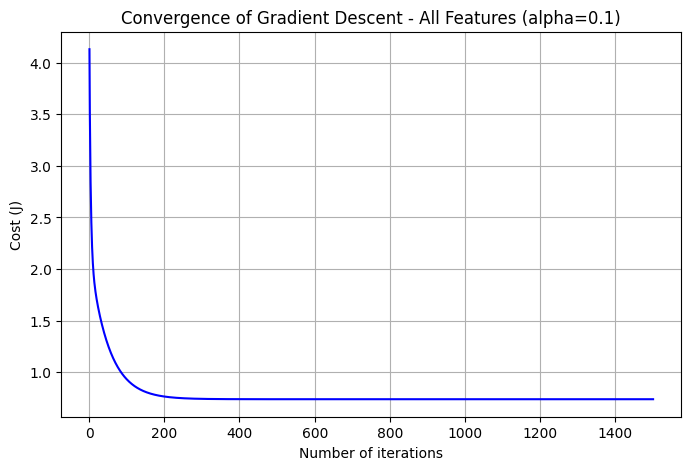

In [ ]:
plt.figure(figsize=(8, 5))
plt.plot(range(1, iterations + 1), cost_history_best, color='blue')
plt.grid(True)
plt.xlabel('Number of iterations')
plt.ylabel('Cost (J)')
plt.title(f'Convergence of Gradient Descent - All Features (alpha={best_alpha_p2})')
plt.show()

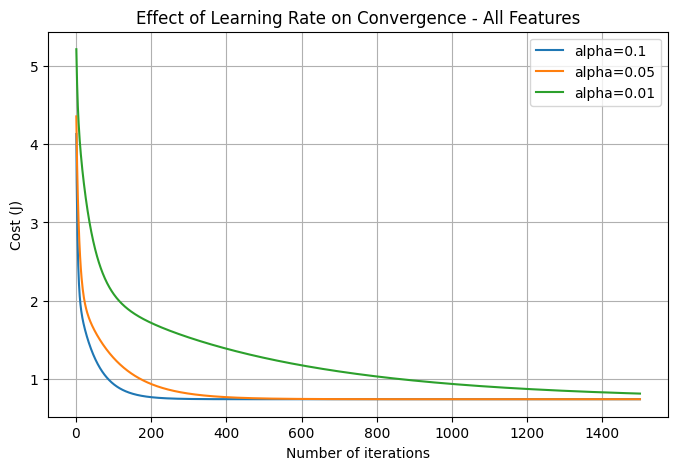

alpha=0.1   final cost=0.738464
alpha=0.05  final cost=0.738465
alpha=0.01  final cost=0.810510


In [ ]:
plt.figure(figsize=(8, 5))
for alpha in learning_rates:
    cost_history = results_p2[alpha][1]
    plt.plot(range(1, iterations + 1), cost_history, label=f'alpha={alpha}')
plt.grid(True)
plt.xlabel('Number of iterations')
plt.ylabel('Cost (J)')
plt.title('Effect of Learning Rate on Convergence - All Features')
plt.legend()
plt.show()

for alpha in learning_rates:
    print(f'alpha={alpha:<5} final cost={results_p2[alpha][1][-1]:.6f}')

In [ ]:
new_points = [(1, 1, 1), (2, 0, 4), (3, 2, 1)]

for point in new_points:
    x_new = np.array([1, *point])  # prepend the bias term (X_0 = 1)
    y_pred = x_new.dot(theta_best)
    print(f'Prediction for (X1, X2, X3) = {point}: Y = {y_pred:.4f}')

Prediction for (X1, X2, X3) = (1, 1, 1): Y = 3.5774
Prediction for (X1, X2, X3) = (2, 0, 4): Y = 0.2443
Prediction for (X1, X2, X3) = (3, 2, 1): Y = 0.1025
